In [ ]:
"""
Same method as in calculs_metriques_methode2.ipynb but with a previous 30Hz resampling

In this file data are processed following Poitras et al. article steps (after resample 100Hz in 30Hz signal) :
    1. Resampling 100Hz in 30Hz signal
    2. Band pass filter to remove outliers : Each of the three signals (x, y and z) from teh 2 sensors (left and right) is filtered with a passband filter 
    3. Maximum threshold of 20.874 m/s²
    4. Minimum threshold of 0.6664 m/s²
    5. Converting into AC : x 0.001664 g
    6. Multiplied by a factor 
    7. Compression of the 30Hz signal in 1Hz signal
    8. Calculation of the euclidian norm (sqrt(x² + y² + z²) for each 1s epoch) as activity counts

"""

Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.signal import butter, freqz
from scipy.signal import filtfilt

Loading files and data

In [2]:
#Path of the file to open
path_left_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1D48140076_(2025-04-16)-IMU_Adele_13h48_15h18.csv" #ADELE
path_right_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1H46190449_(2025-04-16)-IMU_Adele_13h48_15h18.csv"#ADELE

"""
#Recording of useful data only
data_left_wrist = pd.read_csv(path_left_wrist, header = 10, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])
data_right_wrist = pd.read_csv(path_right_wrist, header = 10, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])
"""
#For pieces of files that were cut with "Cut_files.py"
data_left_wrist = pd.read_csv(path_left_wrist, header = 0, usecols = ['Timestamp','Accelerometer X','Accelerometer Y','Accelerometer Z'])
data_right_wrist = pd.read_csv(path_right_wrist, header = 0, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])

#List of the differents sensors to separate data from left [0] and right [1] wrist sensor
lst_sensors = [data_left_wrist, data_right_wrist]
lst_sensor_str = ["left wrist", "right wrist"]

for sensor in lst_sensors:

        #Convertion of the str data into float
        for data_idx in range(len(sensor)) : 
                #Convertion of commas to dots to allow convertion of str data to float data
                sensor.loc[data_idx, "Accelerometer X"] = float(sensor.loc[data_idx, "Accelerometer X"].replace(",","."))
                sensor.loc[data_idx, "Accelerometer Y"] = float(sensor.loc[data_idx, "Accelerometer Y"].replace(",","."))
                sensor.loc[data_idx, "Accelerometer Z"] = float(sensor.loc[data_idx, "Accelerometer Z"].replace(",","."))- 0.981 # -0.981 removes the gravaity factor




1. Resampling 100Hz in 30Hz signal

!!!!!!!!!!!!!!!!!!!!!!!!!!!! A modifier !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [1]:
signal_30Hz = {}
idx_side = 0

for sensor in lst_sensors:
    for key in sensor.keys():
        if key != "Timestamp":
            signal = sensor[key]


            #Zero padding to allow the reshaping
            signal_len = len(signal)
            to_complete = signal_len % 10
            if to_complete != 0:
                padding = 10 - to_complete
                padded_signal = np.pad(signal, (0, padding), mode='constant')
            else:
                padded_signal = signal

            # Reshape in 100 samples epoch (1s epoch)
            reshaped_signal = padded_signal.reshape(-1, 100/30)

            # Sum of the magnitude vector for every 1s epoch = activity count
            signal_30Hz[f"{lst_sensor_str[idx_side]}_{key}"]  = np.sum(reshaped_signal, axis=1)

    idx_side +=1



NameError: name 'lst_sensors' is not defined

2. Band pass Filter to remove outliers

In [ ]:
"""Creation of a band pass butterworth filter with bandwith of 0.13Hz to 2.73Hz and a peak frequency at 0.77Hz.
The design of the filter is based on the description of Peach et al. in the article : "Exploring the ActiLife® filtration algorithm: converting raw acceleration data to counts"."""

#Sampling rate in Hz
fs = 100  

#Frequencies of interest
lowcut = 0.13
highcut = 2.73

#Normalize the frequencies to the Nyquist frequency
nyq = 0.5 * fs
low = lowcut / nyq
high = highcut / nyq

#Design of Butterworth bandpass filter
order = 4  
b, a = butter(order, [low, high], btype='band')

#Signal
filtered_signal_df = {}
idx_side = 0

for sensor in lst_sensors:
    for key in sensor.keys():
        if key != "Timestamp":
            signal = sensor[key]
            
            #Apply the filter
            filtered_signal = filtfilt(b, a, signal)

            #Save the filtered signal
            filtered_signal_df[f"{lst_sensor_str[idx_side]}_{key}"] = np.abs(filtered_signal)
            
    idx_side +=1

print(filtered_signal_df)

{'left wrist_Accelerometer X': array([0.0071170183907532875, 0.004459915104757072, 0.0018055922624252113,
       ..., 0.01011688684537004, 0.009295223369668431,
       0.008451364150543865], shape=(539999,), dtype=object), 'left wrist_Accelerometer Y': array([0.007987049058366388, 0.007842876781621266, 0.007765678634877607,
       ..., 0.002251642438303685, 0.002031512029231299,
       0.0018205871326103706], shape=(539999,), dtype=object), 'left wrist_Accelerometer Z': array([0.00011519567139687856, 0.0035725767598144428,
       0.007041715785317955, ..., 0.0013548348056118549,
       0.0013597190578858325, 0.001336306389265685],
      shape=(539999,), dtype=object), 'right wrist_Accelerometer X': array([0.0017284398636098586, 0.008646683432155218, 0.015552390562217399,
       ..., 0.015130284424421313, 0.013920166572478167,
       0.012694214598613373], shape=(539999,), dtype=object), 'right wrist_Accelerometer Y': array([0.009918654695995701, 0.013993779773321762, 0.0179932803360794

7. Compression of the 30Hz signal in 1Hz signal    

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! A modifier, pour l'instant 100Hz -> 1Hz au lieu de 30Hz -> 1Hz !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [6]:
filtered_compressed_signal_df = {}

for name in filtered_signal_df.keys():
    signal = filtered_signal_df[name]
    print(signal)
    #Zero padding to allow the reshaping
    signal_len = len(signal)
    to_complete = signal_len % 10
    if to_complete != 0:
        padding = 10 - to_complete
        padded_signal = np.pad(signal, (0, padding), mode='constant')
    else:
        padded_signal = signal

    # Reshape in 100 samples epoch (1s epoch)
    reshaped_signal = padded_signal.reshape(-1, 100)

    # Sum of the magnitude vector for every 1s epoch = activity count
    filtered_compressed_signal_df[name] = np.sum(reshaped_signal, axis=1)

"""
#Display
x_axis_time = np.arange(len(activity_count_1s))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, activity_count_1s)
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the filtered data as a function of time")   
plt.show()
"""


[0.0071170183907532875 0.004459915104757072 0.0018055922624252113 ...
 0.01011688684537004 0.009295223369668431 0.008451364150543865]
[0.007987049058366388 0.007842876781621266 0.007765678634877607 ...
 0.002251642438303685 0.002031512029231299 0.0018205871326103706]
[0.00011519567139687856 0.0035725767598144428 0.007041715785317955 ...
 0.0013548348056118549 0.0013597190578858325 0.001336306389265685]
[0.0017284398636098586 0.008646683432155218 0.015552390562217399 ...
 0.015130284424421313 0.013920166572478167 0.012694214598613373]
[0.009918654695995701 0.013993779773321762 0.017993280336079474 ...
 0.011384059940572355 0.01040036382158284 0.00940824143664084]
[0.04140795250858009 0.046259688857028525 0.05124161879288734 ...
 0.03599200390744393 0.032977518209024115 0.029970523228137393]


'\n#Display\nx_axis_time = np.arange(len(activity_count_1s))\nplt.figure(figsize=(10, 6))\nplt.plot(x_axis_time, activity_count_1s)\nplt.xlabel("Time (in sec)")\nplt.ylabel("Value on the magnitude vector (en g)")\nplt.title(f"Graphic representation of the filtered data as a function of time")   \nplt.show()\n'

8. Calculation of VM

In [7]:
activity_counts = {"left" : [], 
        "right" : []}

#Browse every ligns (each period)
for idx_time in range (len(filtered_compressed_signal_df["left wrist_Accelerometer X"])):

    #Initialization to separate left sensor from right sensor
    idx_sensor = 0
    sum_left = 0
    sum_right = 0

    #Browse every axes
    for axis in filtered_compressed_signal_df.keys():

        if idx_sensor <= 2:
            sum_left += np.square(filtered_compressed_signal_df[axis][idx_time])
        
        else:
            sum_right += np.square(filtered_compressed_signal_df[axis][idx_time])
        
        idx_sensor += 1

    activity_counts["left"].append(np.sqrt(sum_left))
    activity_counts["right"].append(np.sqrt(sum_right))
            
        

print(activity_counts)

{'left': [np.float64(9.967087984891467), np.float64(6.307138453722419), np.float64(3.1956470394451872), np.float64(2.8787152567374696), np.float64(2.2799671359039118), np.float64(2.5218305266183974), np.float64(3.7987479996880866), np.float64(3.9027730470176167), np.float64(3.438249190109885), np.float64(7.367300666876795), np.float64(5.085655613349539), np.float64(7.9888575314744115), np.float64(6.418970405551969), np.float64(3.7641126511166156), np.float64(6.472329896036689), np.float64(4.088922217852121), np.float64(1.1365291240478896), np.float64(2.556759933632492), np.float64(2.9060534084160072), np.float64(1.768862301129071), np.float64(2.8841476032940654), np.float64(10.929299657339877), np.float64(11.139833960754054), np.float64(4.1467544710452), np.float64(8.040961933269594), np.float64(4.159469967567816), np.float64(6.794291282724494), np.float64(6.2301428391514175), np.float64(8.971081718682887), np.float64(25.435566848038565), np.float64(16.965169941719253), np.float64(10.4

Display activity count per 1s

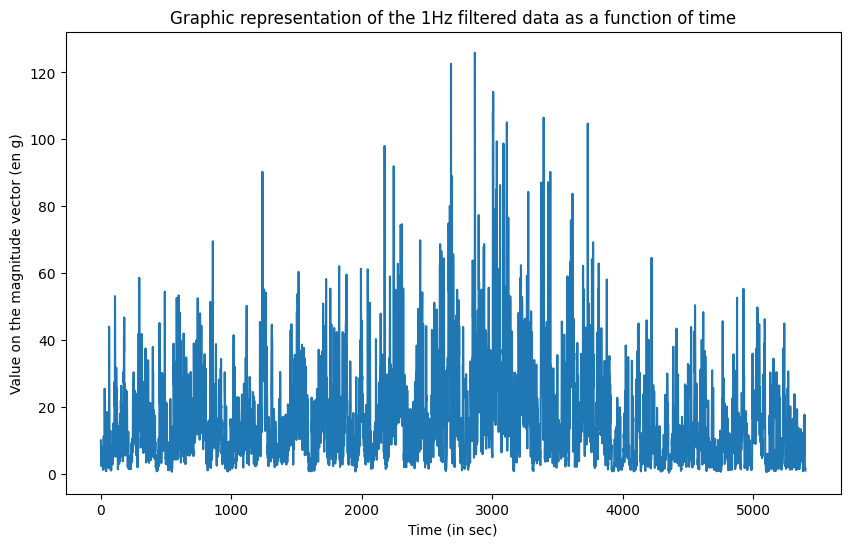

In [13]:
#Display
x_axis_time = np.arange(len(activity_counts["left"]))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time,activity_counts["left"])
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the 1Hz filtered data as a function of time")   
plt.show()

In [9]:
#Mean activity count

mean_AC = np.mean(activity_counts["left"])

print(mean_AC)

16.040776764141075
